# 한우 `LAST_GRADE` Baseline 예측 모델

이 노트북은 등급 예측 모델의 첫 기준선을 만드는 파일입니다.

- 타깃: `LAST_GRADE`
- 모델: RandomForestClassifier
- 평가 지표: Macro-F1-score
- 결측 처리: `-99`를 결측값으로 바꾼 뒤, 숫자형 변수는 평균(mean)으로 채움

주의: 문자형 변수는 평균을 낼 수 없기 때문에 최빈값으로 채운 뒤 원-핫 인코딩합니다.

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 불러오기

`hanwoo_train.csv`는 파일이 크기 때문에 기본값은 20만 행 샘플로 설정했습니다. 전체 데이터를 사용하려면 `USE_SAMPLE = False`로 바꾸면 됩니다.

In [2]:
BASE_DIR = Path('.')
train_path = BASE_DIR / 'hanwoo_train' / 'hanwoo_train.csv'

USE_SAMPLE = True
SAMPLE_ROWS = 200_000

train = pd.read_csv(train_path, nrows=SAMPLE_ROWS if USE_SAMPLE else None)

print('데이터 크기:', train.shape)
display(train.head())

데이터 크기: (200000, 23)


,sido,sigungu,eupmyeondong,stn,ABATT_DATE,JUDGE_DATE,JUDGE_SEX,WEIGHT,BACKFAT,REA,WINDEX,WGRADE,INSFAT,YUKSAK,FATSAK,TISSUE,GROWTH,COST_AMT,AGE,BIRTH_YMD,CATTLE_NO,FARM_UNIQUE_NO,LAST_GRADE
0,강원특별자치도,정선군,북평면,563,2023-01-01,2023-01-02,암,218,3.0,44.0,63.23,A,1.0,6.0,7.0,5.0,9.0,-99.0,76,20160915,mI4i8G0BJ8kWD6gdm77RmTzyuIx6N2ZMaZ7wFXx3xb4=,hqh4Qmh5g+ymbYtqjAeKeA==,3B
1,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,520,12.0,100.0,61.46,B,4.0,5.0,3.0,3.0,3.0,-99.0,32,20200504,tMgfi1p35taO9GH4XN4x0bfO8czy79B8V9NyczRuV+8=,N5qW6dZ91QWCMHg/1kPdlA==,1B
2,경상북도,영주시,이산면,837,2023-01-01,2023-01-02,거세,452,14.0,104.0,61.86,B,9.0,4.0,3.0,1.0,3.0,-99.0,29,20200803,mdsSD4/sB06U68LNT6P/GUwei2ISyIBZ+R04iLw2mX0=,5UbtU8TgV2yu3Y4/jxuNMQ==,1++B
3,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,454,12.0,95.0,61.83,B,9.0,5.0,3.0,1.0,3.0,-99.0,32,20200510,LZWd4YatUD851LyC/LFXuxPW7KEXTwVWQONOwqrkLPI=,N5qW6dZ91QWCMHg/1kPdlA==,1++B
4,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,462,10.0,78.0,61.24,B,4.0,5.0,3.0,3.0,3.0,-99.0,32,20200511,A4FF/dhr8vg7JeW/eqc3922pA69nEaLL/+uoAusZqyU=,N5qW6dZ91QWCMHg/1kPdlA==,1B


## 3. `-99`를 결측값으로 바꾸기

가이드라인에서 결측치는 `-99`로 표기된다고 했으므로, 모델링 전에 `NaN`으로 바꿉니다.

In [3]:
train = train.replace(-99, np.nan)
train = train.replace('-99', np.nan)

missing_summary = []
for col in train.columns:
    missing_summary.append({
        'column': col,
        'missing_count': train[col].isna().sum(),
        'missing_ratio': train[col].isna().mean()
    })

missing_summary = pd.DataFrame(missing_summary).sort_values('missing_count', ascending=False)
display(missing_summary.query('missing_count > 0'))

,column,missing_count,missing_ratio
17,COST_AMT,75434,0.377170
15,TISSUE,601,0.003005
12,INSFAT,600,0.003000
10,WINDEX,598,0.002990
13,YUKSAK,597,0.002985
9,REA,585,0.002925
14,FATSAK,420,0.002100
8,BACKFAT,402,0.002010


## 4. 날짜 변수 만들기

모델에 바로 날짜 문자열을 넣기 어렵기 때문에 도축월, 계절, 판정 지연일 같은 간단한 파생 변수를 만듭니다.

In [4]:
train['ABATT_DATE'] = pd.to_datetime(train['ABATT_DATE'], errors='coerce')
train['JUDGE_DATE'] = pd.to_datetime(train['JUDGE_DATE'], errors='coerce')
train['BIRTH_YMD'] = pd.to_datetime(train['BIRTH_YMD'].astype(str), format='%Y%m%d', errors='coerce')

train['abatt_year'] = train['ABATT_DATE'].dt.year
train['abatt_month'] = train['ABATT_DATE'].dt.month
train['judge_delay'] = (train['JUDGE_DATE'] - train['ABATT_DATE']).dt.days

season_map = {
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'fall', 10: 'fall', 11: 'fall'
}
train['abatt_season'] = train['abatt_month'].map(season_map)

display(train[['ABATT_DATE', 'JUDGE_DATE', 'BIRTH_YMD', 'abatt_year', 'abatt_month', 'abatt_season', 'judge_delay']].head())

,ABATT_DATE,JUDGE_DATE,BIRTH_YMD,abatt_year,abatt_month,abatt_season,judge_delay
0,2023-01-01,2023-01-02,2016-09-15,2023,1,winter,1
1,2023-01-01,2023-01-02,2020-05-04,2023,1,winter,1
2,2023-01-01,2023-01-02,2020-08-03,2023,1,winter,1
3,2023-01-01,2023-01-02,2020-05-10,2023,1,winter,1
4,2023-01-01,2023-01-02,2020-05-11,2023,1,winter,1


## 5. 모델에 사용할 변수 선택

이번 baseline은 가장 기본적인 도체 판정 데이터만 사용합니다.

식별자인 `CATTLE_NO`, `FARM_UNIQUE_NO`는 그대로 넣지 않습니다. 나중에 혈통/농장 집계 변수로 바꿔서 넣는 것이 좋습니다.

In [5]:
target = 'LAST_GRADE'

numeric_features = [
    'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT',
    'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT',
    'AGE', 'abatt_month', 'judge_delay'
]

categorical_features = [
    'sido', 'sigungu', 'JUDGE_SEX', 'WGRADE', 'abatt_season', 'stn'
]

numeric_features = [col for col in numeric_features if col in train.columns]
categorical_features = [col for col in categorical_features if col in train.columns]
features = numeric_features + categorical_features

print('숫자형 변수:', numeric_features)
print('범주형 변수:', categorical_features)
print('타깃:', target)

숫자형 변수: ['WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'INSFAT', 'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT', 'AGE', 'abatt_month', 'judge_delay']
범주형 변수: ['sido', 'sigungu', 'JUDGE_SEX', 'WGRADE', 'abatt_season', 'stn']
타깃: LAST_GRADE


## 6. 학습용 데이터 만들기

`LAST_GRADE`가 없는 행은 정답이 없으므로 제거합니다. 숫자형 변수는 숫자로 변환하고, 변환되지 않는 값은 결측값으로 처리합니다.

In [6]:
model_df = train[features + [target]].copy()
model_df = model_df.dropna(subset=[target])

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

for col in categorical_features:
    model_df[col] = model_df[col].astype('object')

X = model_df[features]
y = model_df[target]

print('모델 데이터 크기:', model_df.shape)
display(y.value_counts().to_frame('count'))

모델 데이터 크기: (200000, 20)


,count
LAST_GRADE,
1+B,25772
1++B,25351
1B,25288
2B,17447
1++A,14870
1+A,12323
1A,12296
1++C,11747
1+C,11725


## 7. Train / Validation 나누기

등급 비율이 train과 validation에 비슷하게 들어가도록 `stratify=y`를 사용합니다.

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)

X_train: (160000, 19)
X_valid: (40000, 19)


## 8. 결측치 평균 대체 + Baseline 모델 만들기

여기서 중요한 부분은 `SimpleImputer(strategy='mean')`입니다.

- 숫자형 변수: train 데이터의 평균값으로 결측치 대체
- 범주형 변수: 최빈값으로 결측치 대체
- 범주형 변수는 OneHotEncoder로 숫자 형태로 변환
- 모델은 RandomForestClassifier 사용

평균값은 validation까지 포함해서 계산하지 않고, train 데이터 기준으로만 계산됩니다. 그래서 데이터 누수를 줄일 수 있습니다.

In [8]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

baseline_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced_subsample'
    ))
])

baseline_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['WEIGHT', 'BACKFAT', 'REA',
                                                   'WINDEX', 'INSFAT', 'YUKSAK',
                                                   'FATSAK', 'TISSUE', 'GROWTH',
                                                   'COST_AMT', 'AGE',
                                                   'abatt_month',
                                                   'judge_delay']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sido', 'sigungu',
                                                   'JUDGE_SEX', 'WGRADE',
                                                   'abatt_season', 'stn'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=18, min_samples_leaf=2,
                                        n_jobs=-1, random_state=42))])

## 9. 모델 학습

In [9]:
baseline_model.fit(X_train, y_train)
print('학습 완료')

학습 완료


## 10. 평균으로 채워진 값 확인

아래 표의 값들이 숫자형 변수 결측치를 채울 때 사용된 평균값입니다.

In [10]:
num_imputer = baseline_model.named_steps['preprocess'].named_transformers_['num'].named_steps['imputer']

mean_fill_values = pd.DataFrame({
    'numeric_feature': numeric_features,
    'mean_used_for_missing': num_imputer.statistics_
})

display(mean_fill_values)

,numeric_feature,mean_used_for_missing
0,WEIGHT,419.434769
1,BACKFAT,13.234062
2,REA,92.888594
3,WINDEX,61.379658
4,INSFAT,5.364901
5,YUKSAK,4.975138
6,FATSAK,3.103215
7,TISSUE,2.188153
8,GROWTH,4.264444
9,COST_AMT,15455.240051


## 11. 예측 및 Macro-F1-score 평가

In [11]:
y_pred = baseline_model.predict(X_valid)

macro_f1 = f1_score(y_valid, y_pred, average='macro')
print('Validation Macro-F1-score:', macro_f1)

print('\nClassification Report')
print(classification_report(y_valid, y_pred))

Validation Macro-F1-score: 0.9319971463138436

Classification Report
              precision    recall  f1-score   support

        1++A       0.98      1.00      0.99      2974
        1++B       0.99      0.99      0.99      5070
        1++C       0.99      1.00      0.99      2349
         1+A       0.93      0.99      0.96      2465
         1+B       0.97      0.98      0.98      5154
         1+C       0.98      0.99      0.98      2345
          1A       0.89      0.95      0.92      2459
          1B       0.95      0.92      0.93      5058
          1C       0.96      0.94      0.95      2170
          2A       0.81      0.90      0.85      1921
          2B       0.93      0.81      0.87      3489
          2C       0.92      0.90      0.91      1326
          3A       0.75      0.90      0.81       770
          3B       0.89      0.85      0.87      1797
          3C       0.91      0.91      0.91       529
          등외       1.00      0.98      0.99       124

    accurac

## 12. Confusion Matrix

어떤 등급을 어떤 등급으로 헷갈리는지 확인합니다.

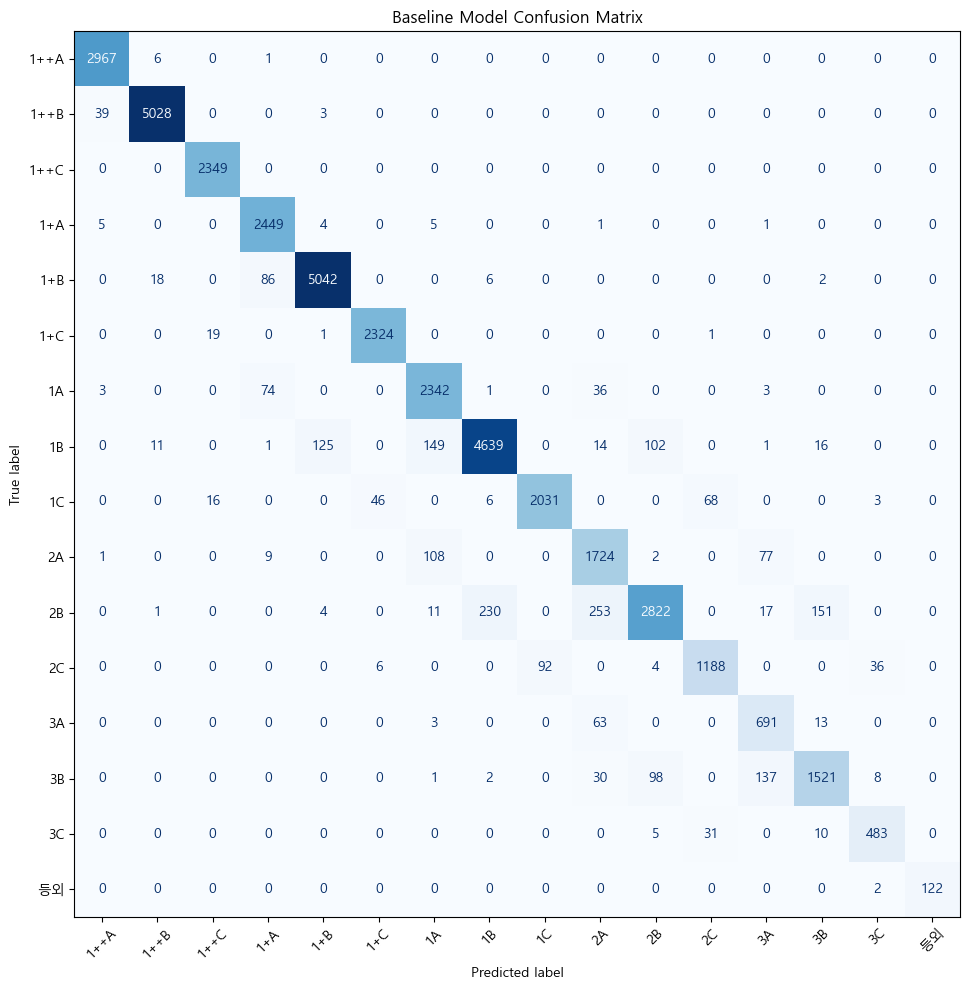

In [12]:
labels = sorted(y_valid.unique())
cm = confusion_matrix(y_valid, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Baseline Model Confusion Matrix')
plt.tight_layout()
plt.show()

## 13. 변수 중요도 확인

RandomForest의 변수 중요도를 확인합니다. 원-핫 인코딩된 범주형 변수는 `변수명_값` 형태로 표시됩니다.

,feature,importance
4,INSFAT,0.171974
7,TISSUE,0.101422
9,COST_AMT,0.088761
3,WINDEX,0.086025
210,WGRADE_B,0.081290
211,WGRADE_C,0.076662
209,WGRADE_A,0.071095
1,BACKFAT,0.051784
0,WEIGHT,0.048985
8,GROWTH,0.040892


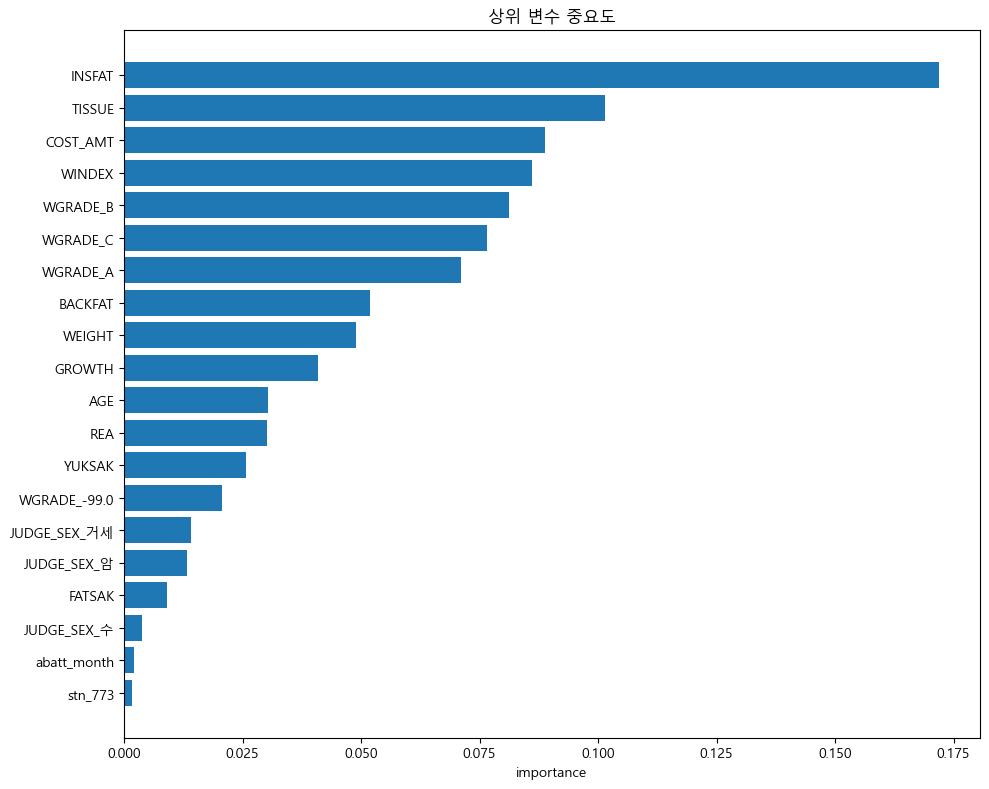

In [13]:
ohe = baseline_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.r_[numeric_features, cat_feature_names]

importances = baseline_model.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

display(feature_importance.head(30))

plt.figure(figsize=(10, 8))
top_n = 20
plt.barh(feature_importance.head(top_n)['feature'][::-1], feature_importance.head(top_n)['importance'][::-1])
plt.title('상위 변수 중요도')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

## 14. 결과 저장

In [14]:
result_df = X_valid.copy()
result_df['y_true'] = y_valid.values
result_df['y_pred'] = y_pred

result_df.to_csv('baseline_validation_predictions.csv', index=False, encoding='utf-8-sig')
feature_importance.to_csv('baseline_feature_importance.csv', index=False, encoding='utf-8-sig')

print('저장 완료: baseline_validation_predictions.csv')
print('저장 완료: baseline_feature_importance.csv')

저장 완료: baseline_validation_predictions.csv
저장 완료: baseline_feature_importance.csv


## 15. 다음 단계

이번 baseline은 도체 판정 데이터만 사용했습니다. 다음에는 아래 순서로 성능을 비교하면 됩니다.

1. 현재 baseline Macro-F1 기록
2. 도축 전 30/90/180일 기상 요약 변수 추가
3. 농장 사육두수, 면적, 사육밀도 추가
4. 폐사율 변수 추가
5. 혈통 집계 변수 추가

각 단계에서 Macro-F1이 얼마나 변하는지 비교하면 보고서에 `기상·축산 데이터 활용 효과`를 설명하기 좋습니다.